▶  Building scale-free social network …
▶  Computing centrality & importance scores …
   Top-3 core nodes (seeds): [6, 7, 4]
▶  Running cascade from top-3 core nodes …
▶  Running robustness experiment …
▶  Rendering visualisation …
✔  Saved visualisation → cascading_network.png


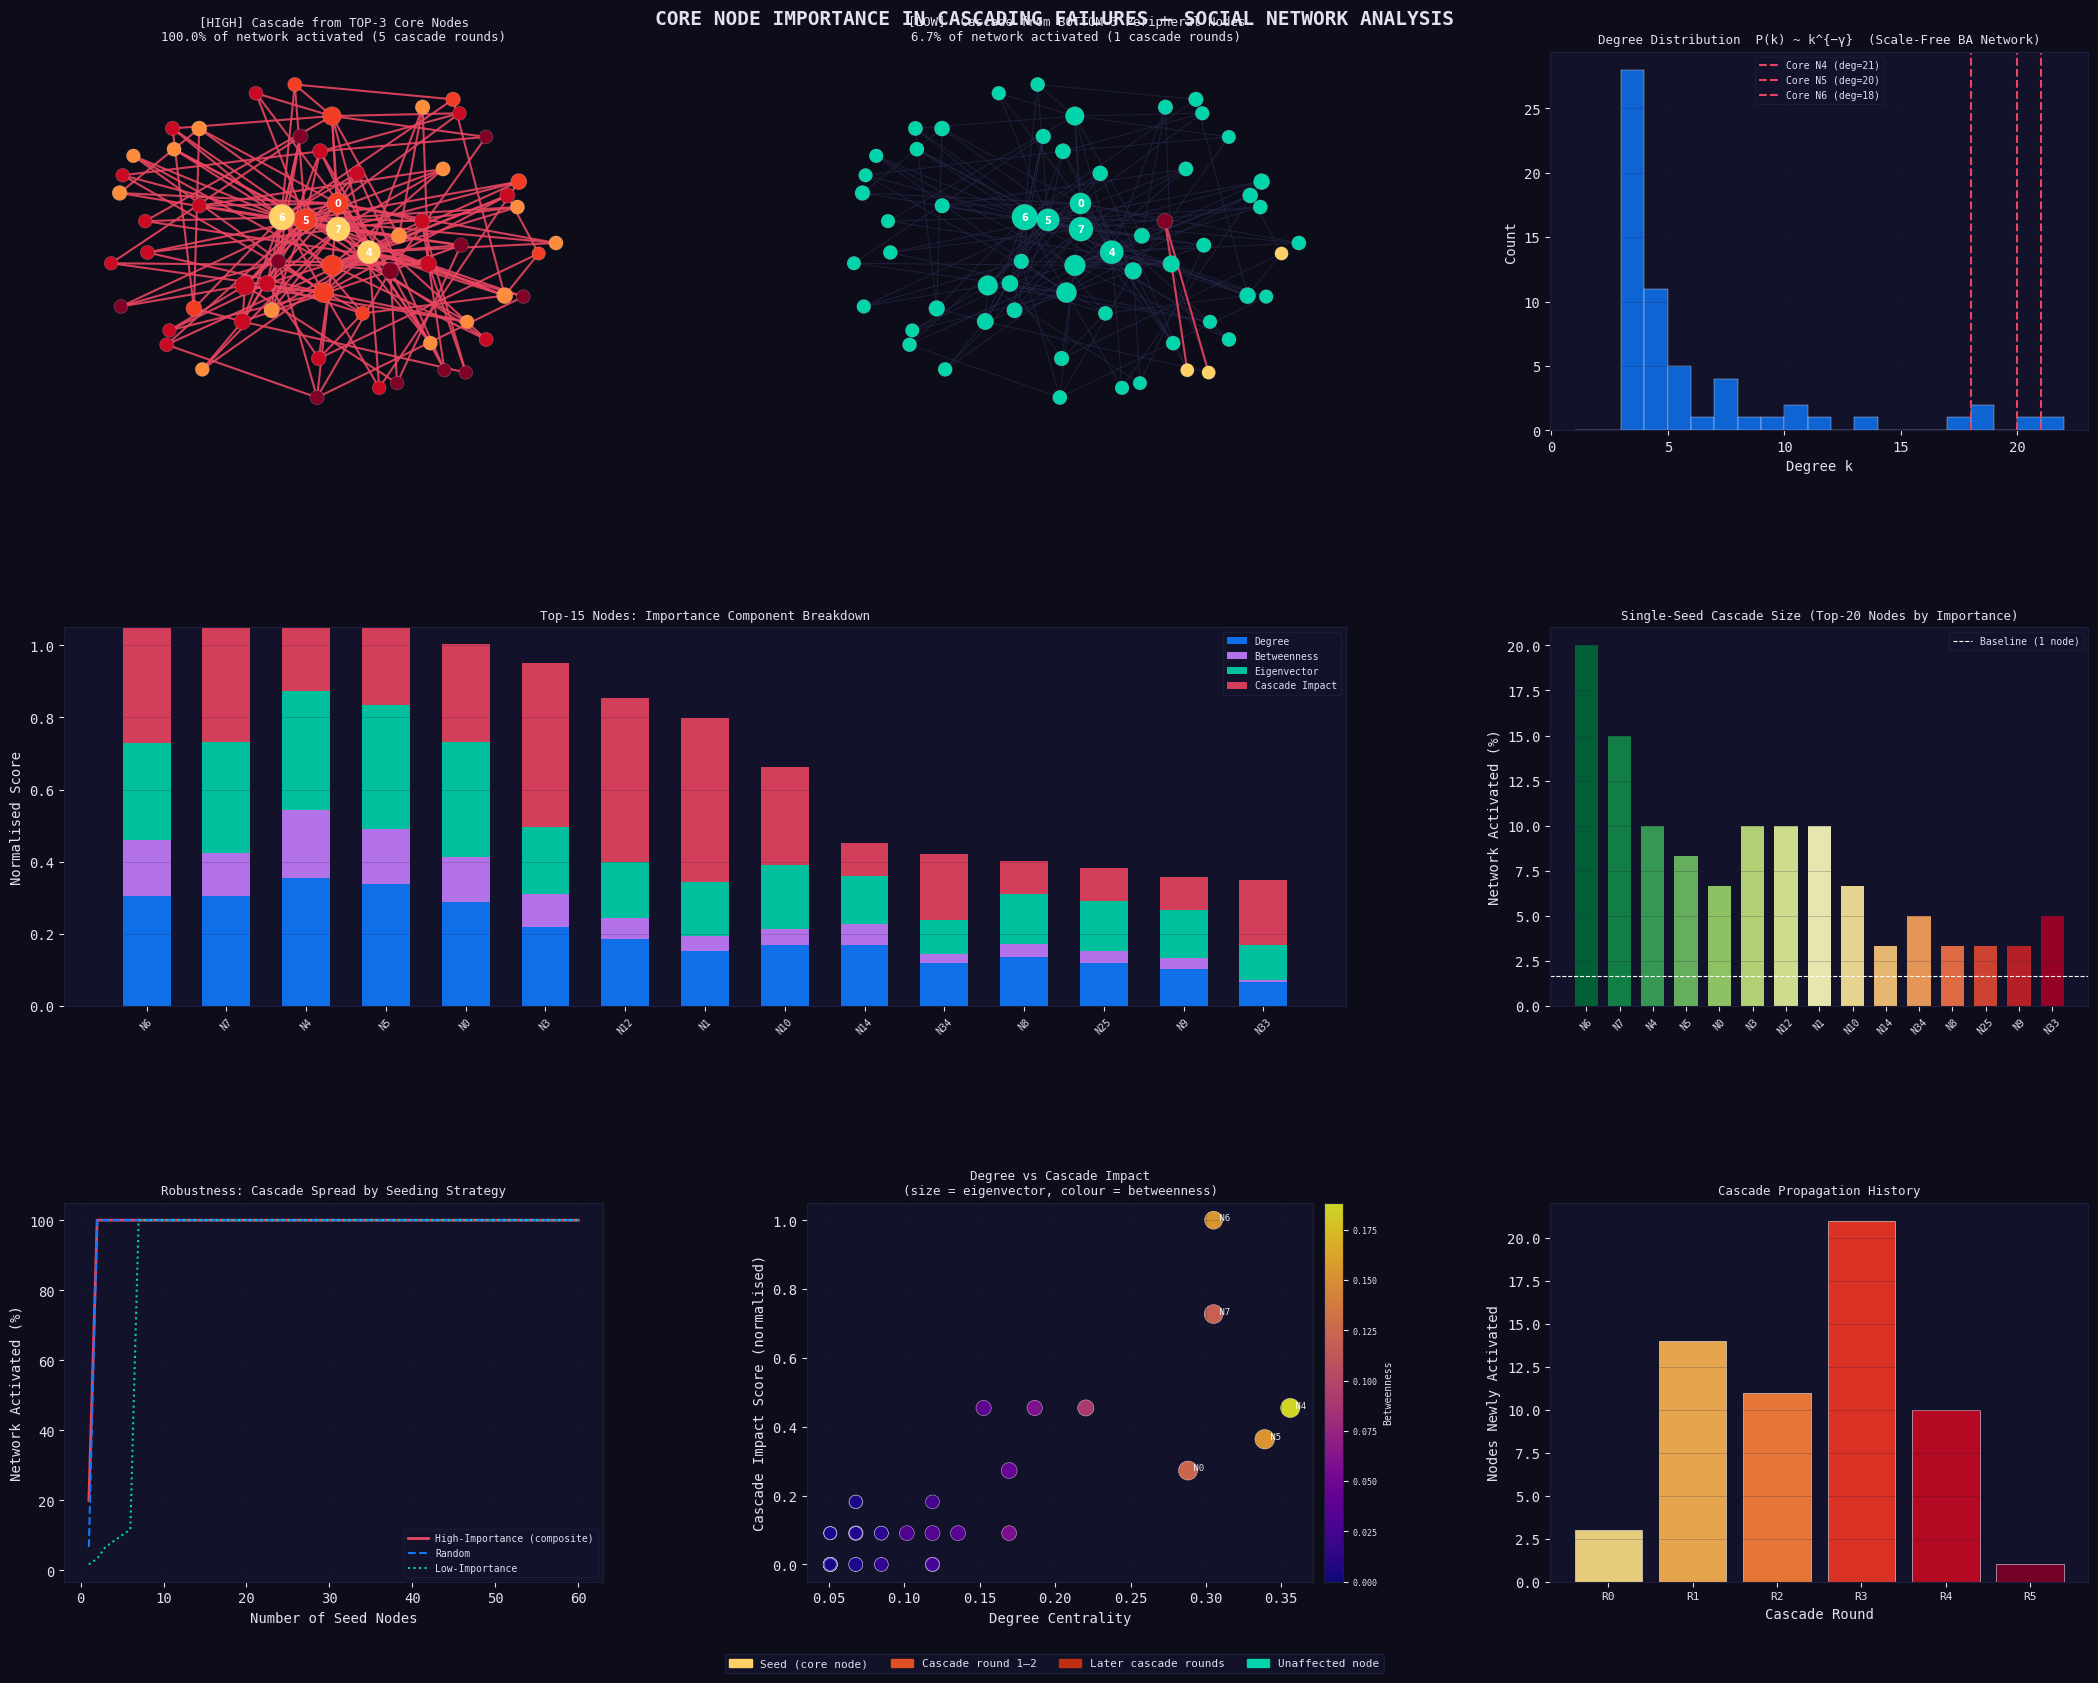

In [7]:
"""
=============================================================================
CORE NODE IMPORTANCE IN CASCADING FAILURES — SOCIAL NETWORK ANALYSIS
=============================================================================

CONCEPT:
  In social networks, certain "core" nodes (highly connected hubs) are
  disproportionately important. When they fail or are removed, cascading
  failures propagate through the network like a chain reaction.

CASCADE MODEL USED — Linear Threshold Model (LTM):
  A node v becomes "active" (failed/infected) if the fraction of its
  active neighbours exceeds its threshold θ_v:

        Σ_{u ∈ N(v), u active} w(u,v)
        ────────────────────────────── ≥ θ_v
              deg(v)

  where w(u,v) is the edge weight (default 1) and deg(v) is the degree.

IMPORTANCE METRICS COMPUTED:
  1. Degree Centrality       — fraction of nodes a node is connected to
  2. Betweenness Centrality  — fraction of shortest paths passing through v
  3. Eigenvector Centrality  — influence accounting for neighbour quality
  4. Cascade Impact Score    — how many nodes fail when v is seeded alone

Author : (your name)
=============================================================================
"""

import random
import copy
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from collections import defaultdict

# ── reproducibility ──────────────────────────────────────────────────────────
random.seed(42)
np.random.seed(42)


# ═════════════════════════════════════════════════════════════════════════════
# 1.  NETWORK CONSTRUCTION
# ═════════════════════════════════════════════════════════════════════════════

def build_social_network(n: int = 60, m: int = 3, seed: int = 42) -> nx.Graph:
    """
    Build a scale-free social network using the Barabási–Albert (BA) model.

    The BA model grows a graph by preferential attachment:
        P(attach to v) ∝ deg(v)
    This produces a power-law degree distribution P(k) ~ k^{-γ}, γ ≈ 3,
    which is characteristic of real social networks (hubs exist).

    Parameters
    ----------
    n   : number of nodes
    m   : edges added per new node  (controls density)
    seed: random seed for reproducibility
    """
    G = nx.barabasi_albert_graph(n, m, seed=seed)

    # Assign a random cascade threshold θ ∈ [0.2, 0.5] to each node.
    # Lower threshold → node fails more easily.
    for v in G.nodes():
        G.nodes[v]['threshold'] = round(random.uniform(0.2, 0.5), 2)
        G.nodes[v]['active']    = False          # not failed initially
        G.nodes[v]['layer']     = 0              # cascade layer (step)

    return G


# ═════════════════════════════════════════════════════════════════════════════
# 2.  LINEAR THRESHOLD CASCADE SIMULATION
# ═════════════════════════════════════════════════════════════════════════════

def run_cascade(G: nx.Graph, seed_nodes: list) -> tuple[nx.Graph, list]:
    """
    Simulate a cascading failure using the Linear Threshold Model.

    Algorithm (synchronous rounds):
    ─────────────────────────────────
    1. Mark seed_nodes as active (layer 0).
    2. In each round t = 1, 2, …:
       For every inactive node v, compute influence fraction:
                 |active neighbours of v|
         f(v) = ──────────────────────────
                       deg(v)
       If f(v) ≥ θ_v  →  activate v at layer t.
    3. Stop when no new activations occur.

    Returns
    -------
    H         : copy of G with updated 'active' and 'layer' attributes
    history   : list of sets — nodes activated at each round
    """
    H = copy.deepcopy(G)

    # Activate seeds
    for v in seed_nodes:
        H.nodes[v]['active'] = True
        H.nodes[v]['layer']  = 0

    history = [set(seed_nodes)]

    t = 1
    while True:
        newly_active = set()
        for v in H.nodes():
            if H.nodes[v]['active']:
                continue                              # already failed

            neighbours  = list(H.neighbors(v))
            if not neighbours:
                continue

            deg_v       = len(neighbours)
            active_nbrs = sum(1 for u in neighbours if H.nodes[u]['active'])

            # ── Linear Threshold Rule ──────────────────────────────────────
            # f(v) = active_neighbours / degree  ≥  θ_v  → activate
            influence = active_nbrs / deg_v
            if influence >= H.nodes[v]['threshold']:
                newly_active.add(v)

        if not newly_active:
            break                                     # cascade stabilised

        for v in newly_active:
            H.nodes[v]['active'] = True
            H.nodes[v]['layer']  = t

        history.append(newly_active)
        t += 1

    return H, history


# ═════════════════════════════════════════════════════════════════════════════
# 3.  CENTRALITY & IMPORTANCE METRICS
# ═════════════════════════════════════════════════════════════════════════════

def compute_importance(G: nx.Graph) -> dict:
    """
    Compute four node-importance scores and a composite rank.

    Formulas
    ────────
    Degree Centrality      C_D(v) = deg(v) / (n - 1)
    Betweenness Centrality C_B(v) = Σ_{s≠v≠t} σ(s,t|v) / σ(s,t)
                                    (σ = number of shortest paths)
    Eigenvector Centrality x_v    = (1/λ) Σ_{u ∈ N(v)} x_u
    Cascade Impact Score   CIS(v) = |nodes activated| when {v} is the seed

    Composite Score        COMP(v) = 0.25·C_D + 0.25·C_B + 0.25·EV + 0.25·CIS
                                     (all scores normalised to [0,1])
    """
    n = G.number_of_nodes()

    # ── standard centrality measures ─────────────────────────────────────
    deg_cen  = nx.degree_centrality(G)           # O(n)
    bet_cen  = nx.betweenness_centrality(G, normalized=True)  # O(n²m)
    eig_cen  = nx.eigenvector_centrality(G, max_iter=1000)    # power iter.

    # ── cascade impact score ──────────────────────────────────────────────
    # For each node, seed it alone and measure total cascade size.
    cis = {}
    for v in G.nodes():
        H, _ = run_cascade(G, [v])
        active_count = sum(1 for u in H.nodes() if H.nodes[u]['active'])
        cis[v] = active_count / n                 # normalise to [0,1]

    # ── normalise CIS to [0,1] ────────────────────────────────────────────
    cis_min, cis_max = min(cis.values()), max(cis.values())
    if cis_max > cis_min:
        cis_norm = {v: (cis[v] - cis_min) / (cis_max - cis_min)
                    for v in G.nodes()}
    else:
        cis_norm = {v: 0.0 for v in G.nodes()}

    # ── composite importance ──────────────────────────────────────────────
    composite = {
        v: 0.25 * deg_cen[v]
         + 0.25 * bet_cen[v]
         + 0.25 * eig_cen[v]
         + 0.25 * cis_norm[v]
        for v in G.nodes()
    }

    return {
        'degree':      deg_cen,
        'betweenness': bet_cen,
        'eigenvector': eig_cen,
        'cis':         cis_norm,
        'composite':   composite,
    }


# ═════════════════════════════════════════════════════════════════════════════
# 4.  ROBUSTNESS EXPERIMENT
# ═════════════════════════════════════════════════════════════════════════════

def robustness_experiment(G: nx.Graph, metrics: dict) -> dict:
    """
    Measure cascade spread when top-k nodes are seeded, for different
    attack strategies:

    • 'composite'  — remove nodes in descending composite importance
    • 'random'     — remove nodes randomly (baseline)
    • 'low_degree' — remove lowest-degree nodes first (best-case baseline)

    Returns fraction of network activated at each removal step.
    """
    n = G.number_of_nodes()
    strategies = {
        'High-Importance (composite)': sorted(G.nodes(),
                                              key=lambda v: metrics['composite'][v],
                                              reverse=True),
        'Random':                      list(np.random.permutation(list(G.nodes()))),
        'Low-Importance':              sorted(G.nodes(),
                                             key=lambda v: metrics['composite'][v]),
    }

    results = {}
    for label, order in strategies.items():
        fracs = []
        for k in range(1, n + 1):
            seeds  = order[:k]
            H, _   = run_cascade(G, seeds)
            active = sum(1 for v in H.nodes() if H.nodes[v]['active'])
            fracs.append(active / n)
        results[label] = fracs

    return results


# ═════════════════════════════════════════════════════════════════════════════
# 5.  VISUALISATION
# ═════════════════════════════════════════════════════════════════════════════

PALETTE = {
    'bg':       '#0d0d1a',
    'panel':    '#12122a',
    'accent1':  '#e94560',   # red — high importance / active
    'accent2':  '#0f7aff',   # blue — cascade spread
    'accent3':  '#00d4aa',   # teal — safe / inactive
    'accent4':  '#ffd166',   # yellow — seed
    'accent5':  '#c77dff',   # purple — betweenness
    'text':     '#e0e0f0',
    'grid':     '#1e1e3c',
}

plt.rcParams.update({
    'figure.facecolor':  PALETTE['bg'],
    'axes.facecolor':    PALETTE['panel'],
    'axes.edgecolor':    PALETTE['grid'],
    'axes.labelcolor':   PALETTE['text'],
    'xtick.color':       PALETTE['text'],
    'ytick.color':       PALETTE['text'],
    'text.color':        PALETTE['text'],
    'grid.color':        PALETTE['grid'],
    'grid.linewidth':    0.5,
    'font.family':       'monospace',
})


def draw_network_state(ax, G, H, metrics, history, seed_nodes, title):
    """
    Draw the network with:
    - Node colour  → cascade layer (depth of failure propagation)
    - Node size    → composite importance score
    - Edge colour  → grey (default) / red if both endpoints active
    """
    pos = nx.spring_layout(G, seed=7, k=1.2)

    # ── layer colourmap: black → yellow → red ────────────────────────────
    max_layer  = max((H.nodes[v]['layer'] for v in H.nodes()
                      if H.nodes[v]['active']), default=1)
    cmap_layers = plt.colormaps['YlOrRd'].resampled(max_layer + 2)

    node_colors = []
    node_sizes  = []
    for v in G.nodes():
        comp  = metrics['composite'][v]
        node_sizes.append(80 + 600 * comp)         # bigger = more important
        if v in seed_nodes:
            node_colors.append(PALETTE['accent4'])  # yellow seed
        elif H.nodes[v]['active']:
            layer_frac = H.nodes[v]['layer'] / max(max_layer, 1)
            node_colors.append(cmap_layers(0.3 + 0.7 * layer_frac))
        else:
            node_colors.append(PALETTE['accent3'])  # teal = safe

    # ── edges ─────────────────────────────────────────────────────────────
    active_edges  = [(u, v) for u, v in G.edges()
                     if H.nodes[u]['active'] and H.nodes[v]['active']]
    passive_edges = [(u, v) for u, v in G.edges()
                     if (u, v) not in active_edges]

    nx.draw_networkx_edges(G, pos, edgelist=passive_edges, ax=ax,
                           edge_color='#2a2a50', width=0.7, alpha=0.6)
    nx.draw_networkx_edges(G, pos, edgelist=active_edges,  ax=ax,
                           edge_color=PALETTE['accent1'],  width=1.5, alpha=0.9)
    nx.draw_networkx_nodes(G, pos, node_color=node_colors,
                           node_size=node_sizes, ax=ax, linewidths=0.5,
                           edgecolors='#ffffff40')

    # ── label top-5 most important nodes ─────────────────────────────────
    top5 = sorted(metrics['composite'], key=metrics['composite'].get, reverse=True)[:5]
    labels = {v: str(v) for v in top5}
    nx.draw_networkx_labels(G, pos, labels=labels, ax=ax,
                            font_size=7, font_color='white', font_weight='bold')

    active_pct = 100 * sum(1 for v in H.nodes() if H.nodes[v]['active']) / G.number_of_nodes()
    ax.set_title(f'{title}\n{active_pct:.1f}% of network activated '
                 f'({len(history)-1} cascade rounds)',
                 fontsize=9, pad=8, color=PALETTE['text'])
    ax.axis('off')


def draw_importance_bar(ax, metrics, top_n=15):
    """
    Stacked bar chart showing the four importance components for top-N nodes,
    sorted by composite score (highest first).
    """
    ranked = sorted(metrics['composite'], key=metrics['composite'].get, reverse=True)[:top_n]

    x       = np.arange(top_n)
    deg_v   = [metrics['degree'][v]      for v in ranked]
    bet_v   = [metrics['betweenness'][v] for v in ranked]
    eig_v   = [metrics['eigenvector'][v] for v in ranked]
    cis_v   = [metrics['cis'][v]         for v in ranked]

    bar_kw  = dict(width=0.6, alpha=0.9)
    b1 = ax.bar(x, deg_v, label='Degree',       color=PALETTE['accent2'],  **bar_kw)
    b2 = ax.bar(x, bet_v, label='Betweenness',  color=PALETTE['accent5'],
                bottom=deg_v, **bar_kw)
    b3 = ax.bar(x, eig_v, label='Eigenvector',  color=PALETTE['accent3'],
                bottom=[d+b for d,b in zip(deg_v, bet_v)], **bar_kw)
    b4 = ax.bar(x, cis_v, label='Cascade Impact', color=PALETTE['accent1'],
                bottom=[d+b+e for d,b,e in zip(deg_v, bet_v, eig_v)], **bar_kw)

    ax.set_xticks(x)
    ax.set_xticklabels([f'N{v}' for v in ranked], rotation=45, fontsize=7)
    ax.set_ylabel('Normalised Score')
    ax.set_title('Top-15 Nodes: Importance Component Breakdown', fontsize=9, pad=6)
    ax.legend(fontsize=7, loc='upper right',
              facecolor=PALETTE['panel'], edgecolor=PALETTE['grid'])
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, 1.05)


def draw_cascade_size_vs_seed(ax, G, metrics, top_n=20):
    """
    Bar chart — for the top-N nodes, how many nodes does each seed alone activate?
    Demonstrates that high-importance seeds trigger larger cascades.

    Cascade size ∝ composite importance (positive correlation expected).
    """
    ranked = sorted(metrics['composite'], key=metrics['composite'].get, reverse=True)[:top_n]
    sizes  = []
    n      = G.number_of_nodes()

    for v in ranked:
        H, _ = run_cascade(G, [v])
        sizes.append(100 * sum(1 for u in H.nodes() if H.nodes[u]['active']) / n)

    colors = plt.colormaps['RdYlGn_r'](np.linspace(0, 1, top_n))
    bars   = ax.bar(range(top_n), sizes, color=colors, alpha=0.9, width=0.7)

    ax.set_xticks(range(top_n))
    ax.set_xticklabels([f'N{v}' for v in ranked], rotation=45, fontsize=7)
    ax.set_ylabel('Network Activated (%)')
    ax.set_title('Single-Seed Cascade Size (Top-20 Nodes by Importance)', fontsize=9, pad=6)
    ax.axhline(100 * 1/n, color='white', linestyle='--', linewidth=0.8,
               label='Baseline (1 node)')
    ax.legend(fontsize=7, facecolor=PALETTE['panel'], edgecolor=PALETTE['grid'])
    ax.grid(axis='y', alpha=0.3)


def draw_robustness_curves(ax, robustness):
    """
    Robustness curve: fraction of network activated vs. number of seeds.

    High-importance seeds → steep early rise → vulnerable network.
    Random seeds          → gradual rise     → expected behaviour.
    Low-importance seeds  → slow rise        → resilient to low-degree attacks.
    """
    styles = {
        'High-Importance (composite)': (PALETTE['accent1'], '-',  2.0),
        'Random':                      (PALETTE['accent2'], '--', 1.5),
        'Low-Importance':              (PALETTE['accent3'], ':',  1.5),
    }
    for label, fracs in robustness.items():
        color, ls, lw = styles[label]
        ax.plot(range(1, len(fracs)+1), [f*100 for f in fracs],
                label=label, color=color, linestyle=ls, linewidth=lw)

    ax.set_xlabel('Number of Seed Nodes')
    ax.set_ylabel('Network Activated (%)')
    ax.set_title('Robustness: Cascade Spread by Seeding Strategy', fontsize=9, pad=6)
    ax.legend(fontsize=7, facecolor=PALETTE['panel'], edgecolor=PALETTE['grid'])
    ax.grid(alpha=0.3)


def draw_centrality_scatter(ax, metrics):
    """
    Scatter plot: Degree Centrality vs Cascade Impact Score.

    Expected: positive correlation — well-connected nodes cause larger cascades.
    Colour encodes betweenness centrality (bridge nodes stand out).
    """
    nodes = list(metrics['degree'].keys())
    x     = [metrics['degree'][v]      for v in nodes]
    y     = [metrics['cis'][v]         for v in nodes]
    c     = [metrics['betweenness'][v] for v in nodes]
    s     = [60 + 400 * metrics['eigenvector'][v] for v in nodes]

    sc = ax.scatter(x, y, c=c, s=s, cmap='plasma', alpha=0.85,
                    edgecolors='white', linewidths=0.3)

    cbar = plt.colorbar(sc, ax=ax, fraction=0.04, pad=0.02)
    cbar.set_label('Betweenness', fontsize=7)
    cbar.ax.tick_params(labelsize=6)

    # annotate top-5 composite nodes
    top5 = sorted(metrics['composite'], key=metrics['composite'].get, reverse=True)[:5]
    for v in top5:
        ax.annotate(f' N{v}', (metrics['degree'][v], metrics['cis'][v]),
                    fontsize=6.5, color='white', alpha=0.9)

    ax.set_xlabel('Degree Centrality')
    ax.set_ylabel('Cascade Impact Score (normalised)')
    ax.set_title('Degree vs Cascade Impact\n(size = eigenvector, colour = betweenness)',
                 fontsize=9, pad=6)
    ax.grid(alpha=0.3)


def draw_degree_distribution(ax, G, metrics):
    """
    Power-law degree distribution of the BA scale-free network.
    P(k) ~ k^{-γ} — most nodes have low degree, a few hubs dominate.
    Vertical lines mark the top-3 'core' nodes.
    """
    degrees = [d for _, d in G.degree()]
    ax.hist(degrees, bins=range(1, max(degrees)+2),
            color=PALETTE['accent2'], alpha=0.8, edgecolor='white', linewidth=0.3)

    top3 = sorted(metrics['degree'], key=metrics['degree'].get, reverse=True)[:3]
    for v in top3:
        deg_v = G.degree(v)
        ax.axvline(deg_v, color=PALETTE['accent1'], linewidth=1.5,
                   linestyle='--', label=f'Core N{v} (deg={deg_v})')

    ax.set_xlabel('Degree k')
    ax.set_ylabel('Count')
    ax.set_title('Degree Distribution  P(k) ~ k^{−γ}  (Scale-Free BA Network)',
                 fontsize=9, pad=6)
    ax.legend(fontsize=7, facecolor=PALETTE['panel'], edgecolor=PALETTE['grid'])
    ax.grid(alpha=0.3)


def draw_cascade_history(ax, history, n_nodes):
    """
    Bar chart of new activations per cascade round.
    Round 0 = seed nodes; subsequent rounds = propagated failures.
    """
    counts = [len(layer) for layer in history]
    colors = plt.colormaps['YlOrRd'](np.linspace(0.2, 1.0, len(counts)))
    ax.bar(range(len(counts)), counts, color=colors, alpha=0.9,
           edgecolor='white', linewidth=0.4)
    ax.set_xlabel('Cascade Round')
    ax.set_ylabel('Nodes Newly Activated')
    ax.set_title('Cascade Propagation History', fontsize=9, pad=6)
    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels([f'R{i}' for i in range(len(counts))], fontsize=8)
    ax.grid(axis='y', alpha=0.3)


# ═════════════════════════════════════════════════════════════════════════════
# 6.  MAIN
# ═════════════════════════════════════════════════════════════════════════════

def main():
    print("▶  Building scale-free social network …")
    G = build_social_network(n=60, m=3)

    print("▶  Computing centrality & importance scores …")
    metrics = compute_importance(G)

    # Pick top-3 composite nodes as seeds for the illustrated cascade
    top3_seeds = sorted(metrics['composite'],
                        key=metrics['composite'].get, reverse=True)[:3]
    print(f"   Top-3 core nodes (seeds): {top3_seeds}")

    print("▶  Running cascade from top-3 core nodes …")
    H_top, hist_top = run_cascade(G, top3_seeds)

    # Compare: cascade from 3 random low-importance nodes
    low3_seeds = sorted(metrics['composite'],
                        key=metrics['composite'].get)[:3]
    H_low, hist_low = run_cascade(G, low3_seeds)

    print("▶  Running robustness experiment …")
    robustness = robustness_experiment(G, metrics)

    # ── Layout ───────────────────────────────────────────────────────────
    print("▶  Rendering visualisation …")
    fig = plt.figure(figsize=(22, 17), facecolor=PALETTE['bg'])
    fig.suptitle('CORE NODE IMPORTANCE IN CASCADING FAILURES — SOCIAL NETWORK ANALYSIS',
                 fontsize=14, fontweight='bold', color=PALETTE['text'], y=0.985)

    gs = GridSpec(3, 3, figure=fig, hspace=0.52, wspace=0.38,
                  left=0.05, right=0.97, top=0.96, bottom=0.06)

    ax_net_top = fig.add_subplot(gs[0, 0])
    ax_net_low = fig.add_subplot(gs[0, 1])
    ax_deg_dis = fig.add_subplot(gs[0, 2])

    ax_imp_bar = fig.add_subplot(gs[1, 0:2])
    ax_cascade = fig.add_subplot(gs[1, 2])

    ax_robust  = fig.add_subplot(gs[2, 0])
    ax_scatter = fig.add_subplot(gs[2, 1])
    ax_history = fig.add_subplot(gs[2, 2])

    # ── Row 0 ─────────────────────────────────────────────────────────────
    draw_network_state(ax_net_top, G, H_top, metrics, hist_top, top3_seeds,
                       '[HIGH] Cascade from TOP-3 Core Nodes')
    draw_network_state(ax_net_low, G, H_low, metrics, hist_low, low3_seeds,
                       '[LOW]  Cascade from BOTTOM-3 Peripheral Nodes')
    draw_degree_distribution(ax_deg_dis, G, metrics)

    # ── Row 1 ─────────────────────────────────────────────────────────────
    draw_importance_bar(ax_imp_bar, metrics, top_n=15)
    draw_cascade_size_vs_seed(ax_cascade, G, metrics, top_n=15)

    # ── Row 2 ─────────────────────────────────────────────────────────────
    draw_robustness_curves(ax_robust, robustness)
    draw_centrality_scatter(ax_scatter, metrics)
    draw_cascade_history(ax_history, hist_top, G.number_of_nodes())

    # ── legend for network maps ───────────────────────────────────────────
    legend_patches = [
        mpatches.Patch(color=PALETTE['accent4'], label='Seed (core node)'),
        mpatches.Patch(color='#e05020',          label='Cascade round 1–2'),
        mpatches.Patch(color='#c03010',          label='Later cascade rounds'),
        mpatches.Patch(color=PALETTE['accent3'], label='Unaffected node'),
    ]
    fig.legend(handles=legend_patches, loc='lower center', ncol=4,
               fontsize=8, facecolor=PALETTE['panel'],
               edgecolor=PALETTE['grid'], framealpha=0.9,
               bbox_to_anchor=(0.5, 0.003))

    out = 'cascading_network.png'
    plt.savefig(out, dpi=160, bbox_inches='tight', facecolor=PALETTE['bg'])
    print(f"✔  Saved visualisation → {out}")
    plt.show()


if __name__ == '__main__':
    main()
